# 01 - Data Exploration
Exploring `data/processed/cleaned_dataset.csv` before feature engineering and modelling.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/cleaned_dataset.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.shape

(49224, 17)

## 1. Basic overview

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49224 entries, 0 to 49223
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         49224 non-null  datetime64[us]
 1   station_id        49224 non-null  int64         
 2   road              49224 non-null  str           
 3   lga               49224 non-null  str           
 4   volume_light      49224 non-null  float64       
 5   volume_heavy      49224 non-null  float64       
 6   max_temp          49224 non-null  float64       
 7   rainfall          49224 non-null  float64       
 8   hour_of_day       49224 non-null  int64         
 9   day_of_week       49224 non-null  str           
 10  is_weekend        49224 non-null  bool          
 11  month             49224 non-null  int64         
 12  public_holiday    49224 non-null  int64         
 13  school_holiday    49224 non-null  int64         
 14  co2_estimate      49224 non-null 

In [3]:
df.describe()

,timestamp,station_id,volume_light,volume_heavy,max_temp,rainfall,hour_of_day,month,public_holiday,school_holiday,co2_estimate
count,49224,49224.000000,49224.000000,49224.000000,49224.000000,49224.000000,49224.000000,49224.000000,49224.0,49224.000000,49224.000000
mean,2025-01-02 09:27:50.112140,36566.550951,1707.367402,190.691451,24.099805,2.651390,11.500000,6.518771,0.0,0.007314,594.848741
min,2024-01-01 00:00:00,7272.000000,0.000000,0.000000,11.200000,0.000000,0.000000,1.000000,0.0,0.000000,0.000000
25%,2024-06-22 05:45:00,7272.000000,367.000000,37.000000,19.500000,0.000000,5.750000,4.000000,0.0,0.000000,127.956640
50%,2025-01-05 03:30:00,50240.000000,973.000000,87.000000,24.200000,0.000000,11.500000,6.000000,0.0,0.000000,317.209830
75%,2025-07-11 01:15:00,50260.000000,3049.000000,282.000000,27.800000,1.000000,17.250000,9.000000,0.0,0.000000,1089.894400
max,2025-12-31 23:00:00,50260.000000,5773.000000,935.000000,42.300000,124.400000,23.000000,12.000000,0.0,1.000000,1981.927220
std,NaN,20021.393370,1632.892088,214.923901,5.632726,9.043269,6.922257,3.396625,0.0,0.085207,570.407057


In [4]:
print('Rows with imputed max_temp:', df['max_temp_imputed'].sum(), f"({df['max_temp_imputed'].mean()*100:.2f}%)")
print('Rows with imputed rainfall:', df['rainfall_imputed'].sum(), f"({df['rainfall_imputed'].mean()*100:.2f}%)")

Rows with imputed max_temp: 48 (0.10%)
Rows with imputed rainfall: 744 (1.51%)


## 2. Time patterns in CO2

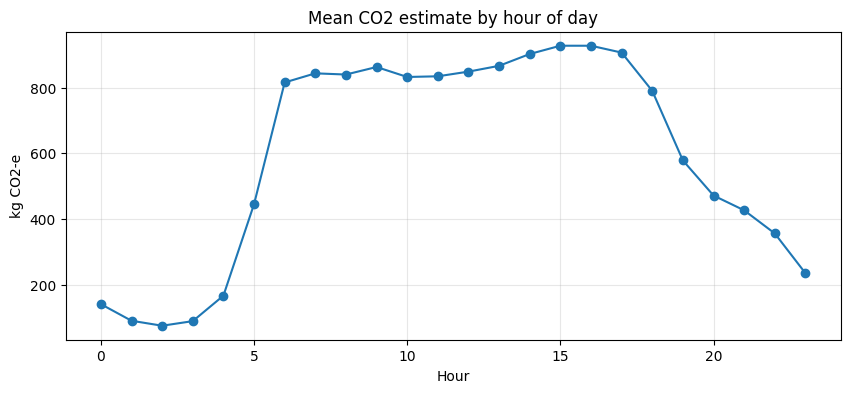

In [5]:
hourly = df.groupby('hour_of_day')['co2_estimate'].mean()
hourly.plot(kind='line', marker='o', figsize=(10,4), title='Mean CO2 estimate by hour of day')
plt.ylabel('kg CO2-e')
plt.xlabel('Hour')
plt.grid(alpha=0.3)
plt.show()

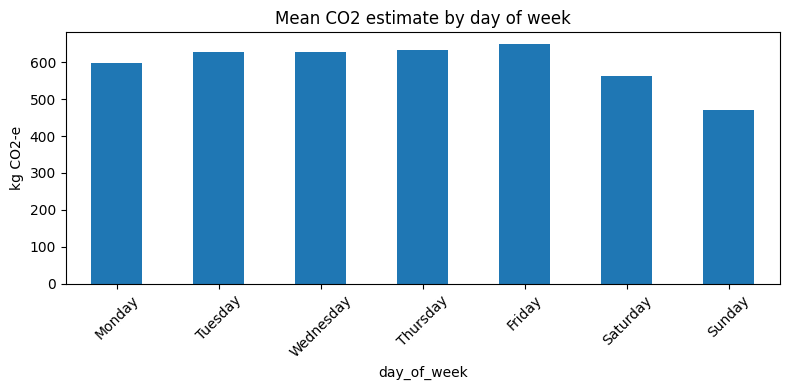

In [6]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df.groupby('day_of_week')['co2_estimate'].mean().reindex(day_order)
daily.plot(kind='bar', figsize=(8,4), title='Mean CO2 estimate by day of week')
plt.ylabel('kg CO2-e')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
df.groupby('is_weekend')['co2_estimate'].mean()

is_weekend
False    625.899591
True     516.474688
Name: co2_estimate, dtype: float64

## 3. Comparison across stations

In [8]:
df.groupby('road')['co2_estimate'].agg(['mean','median','std']).round(1)

,mean,median,std
road,,,
Briens Road,867.5,795.5,568.8
Edgar Street,107.8,122.5,60.2
Silverwater Road,776.4,679.7,546.2


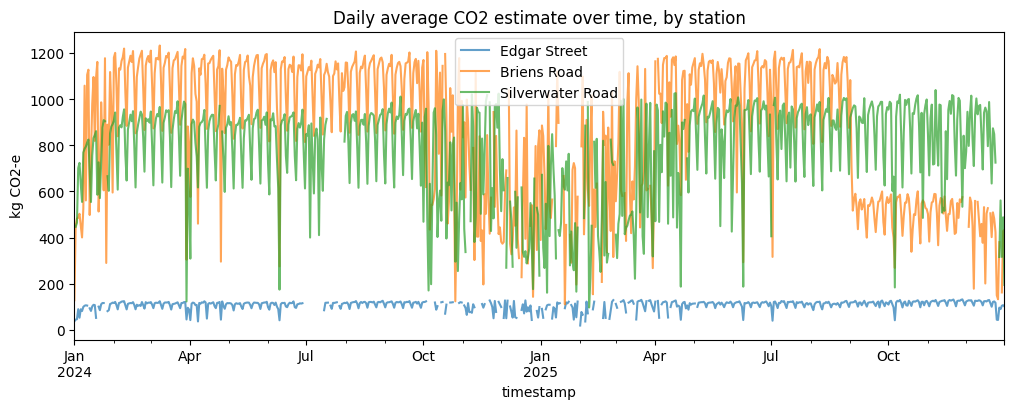

In [9]:
for road in df['road'].unique():
    subset = df[df['road']==road].set_index('timestamp')['co2_estimate']
    daily_avg = subset.resample('D').mean()
    daily_avg.plot(figsize=(12,4), label=road, alpha=0.7)
plt.legend()
plt.title('Daily average CO2 estimate over time, by station')
plt.ylabel('kg CO2-e')
plt.show()

## 4. Correlation with target

**Important:** `volume_light` and `volume_heavy` are expected to correlate very strongly with `co2_estimate` since they are direct inputs to the formula that computes it (see DATA.md, "Target variable" section). This is not a meaningful discovery for RQ1/RQ4 — it's circular by construction. The features actually worth interpreting via SHAP are the ones *not* used to compute the target: weather and temporal features.

In [10]:
numeric_cols = ['volume_light','volume_heavy','max_temp','rainfall','hour_of_day','month','co2_estimate']
corr = df[numeric_cols].corr()
corr['co2_estimate'].sort_values(ascending=False)

co2_estimate    1.000000
volume_light    0.985566
volume_heavy    0.895665
hour_of_day     0.180939
rainfall        0.006647
month          -0.045696
max_temp       -0.144534
Name: co2_estimate, dtype: float64

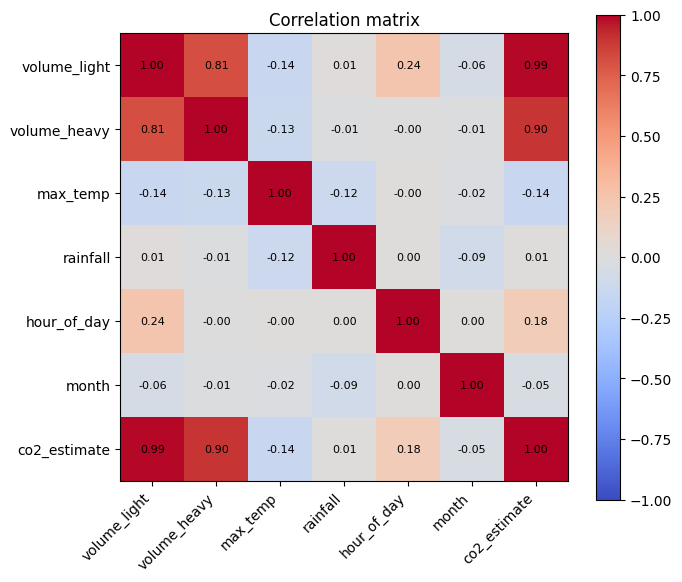

In [11]:
import numpy as np
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

## 5. Weather relationship (excluding volume)

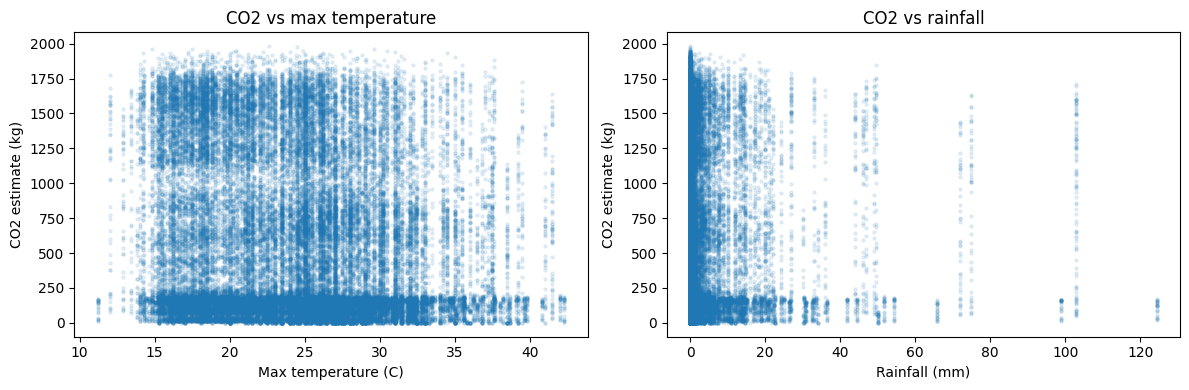

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].scatter(df['max_temp'], df['co2_estimate'], alpha=0.1, s=5)
axes[0].set_xlabel('Max temperature (C)')
axes[0].set_ylabel('CO2 estimate (kg)')
axes[0].set_title('CO2 vs max temperature')

axes[1].scatter(df['rainfall'], df['co2_estimate'], alpha=0.1, s=5)
axes[1].set_xlabel('Rainfall (mm)')
axes[1].set_ylabel('CO2 estimate (kg)')
axes[1].set_title('CO2 vs rainfall')
plt.tight_layout()
plt.show()